# Same square support, different density

This notebook explains the Phase 5 witness: two point laws have exactly the same square support, but assign different probabilities to the four corners. Their support topology is therefore the same, while their metric-measure laws, and consequently their fixed-size barcode laws, can differ.

We use the four corners of the unit square. The uniform law is $p=(0.25,0.25,0.25,0.25)$ and the concentrated full-support law is $q=(0.70,0.10,0.10,0.10)$.

In [1]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(20260820)

points = np.array([[0., 0.], [1., 0.], [1., 1.], [0., 1.]])
labels = ['A', 'B', 'C', 'D']
p = np.array([0.25, 0.25, 0.25, 0.25])
q = np.array([0.70, 0.10, 0.10, 0.10])

def tv(distribution_1, distribution_2):
    return 0.5 * np.abs(distribution_1 - distribution_2).sum()

print('Point-law total variation:', tv(p, q))

Point-law total variation: 0.45


## The geometry is unchanged, but the sampling density is not

The dots have the same locations in both panels. Their sizes represent probability mass. Under $q$, repeated samples are much more likely to land at corner A. Thus a point-law test can distinguish the two laws even though a support-only topological description cannot.

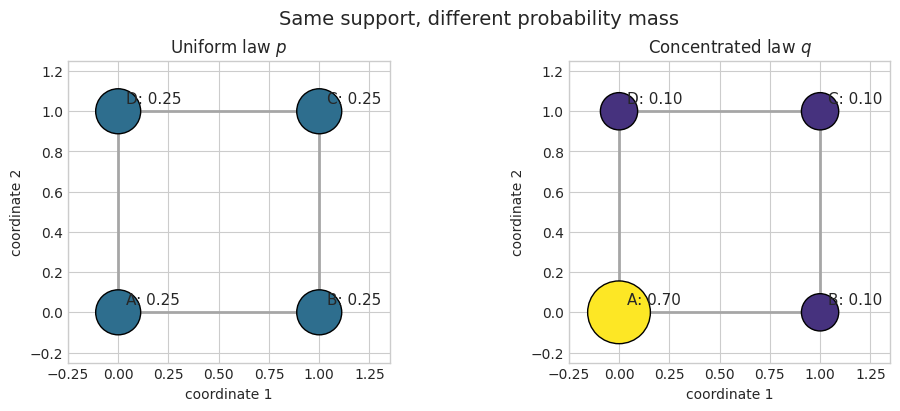

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, weights, title in zip(axes, [p, q], ['Uniform law $p$', 'Concentrated law $q$']):
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='0.65', lw=2)
    ax.scatter(points[:, 0], points[:, 1], s=500 + 2200 * weights, c=weights,
               cmap='viridis', vmin=0, vmax=0.7, edgecolor='black', zorder=3)
    for (x, y), label, weight in zip(points, labels, weights):
        ax.text(x + 0.04, y + 0.04, f'{label}: {weight:.2f}', fontsize=11)
    ax.set(title=title, xlim=(-0.25, 1.35), ylim=(-0.25, 1.25), aspect='equal')
    ax.set_xlabel('coordinate 1'); ax.set_ylabel('coordinate 2')
fig.suptitle('Same support, different probability mass', fontsize=14)
plt.show()

## Why the $m=2$ barcode law differs

For a two-point cloud on this square, the finite degree-0 persistence is determined by the distance between the two sampled points. There are only three observable distance types: repeated corner ($0$), adjacent corners ($1$), and opposite corners ($\sqrt{2}$). This is a simple barcode proxy for the exact $H_0$ persistence calculation, where the death time is distance divided by two.

The induced distributions over these three barcode types are computed exactly below. Because this is a pushforward of the point law, its total variation cannot exceed the point-law total variation.

In [3]:
distance = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=-1)
def pair_type(d):
    if np.isclose(d, 0): return 'same corner'
    if np.isclose(d, 1): return 'adjacent corners'
    return 'opposite corners'

types = ['same corner', 'adjacent corners', 'opposite corners']
def pair_type_distribution(weights):
    out = {kind: 0.0 for kind in types}
    for i, j in itertools.product(range(4), repeat=2):
        out[pair_type(distance[i, j])] += weights[i] * weights[j]
    return np.array([out[kind] for kind in types])

barcode_p = pair_type_distribution(p)
barcode_q = pair_type_distribution(q)
comparison = pd.DataFrame({'barcode type': types, 'under p': barcode_p, 'under q': barcode_q})
print(comparison.to_string(index=False, formatters={'under p': '{:.3f}'.format, 'under q': '{:.3f}'.format}))
print('Point-law TV =', tv(p, q))
print('m=2 barcode-law TV =', tv(barcode_p, barcode_q))

    barcode type under p under q
     same corner   0.250   0.520
adjacent corners   0.500   0.320
opposite corners   0.250   0.160
Point-law TV = 0.45
m=2 barcode-law TV = 0.26999999999999996


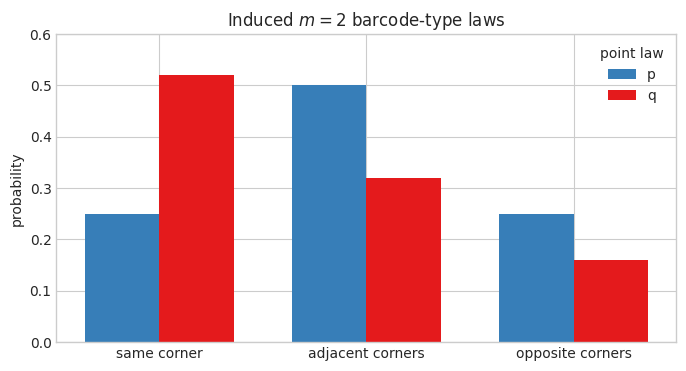

In [4]:
x = np.arange(len(types))
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.36
ax.bar(x - width/2, barcode_p, width, label='p', color='#377eb8')
ax.bar(x + width/2, barcode_q, width, label='q', color='#e41a1c')
ax.set_xticks(x, types); ax.set_ylim(0, 0.6)
ax.set_ylabel('probability'); ax.set_title('Induced $m=2$ barcode-type laws')
ax.legend(title='point law')
plt.show()

## The locked $m=25$ lower bound

Let $E$ be the event that all four corners appear at least once in a sample of 25 points. The probabilities under $p$ and $q$ are obtained by inclusion-exclusion. Since total variation is the largest possible difference in event probabilities, $|P_p(E)-P_q(E)|$ is a lower bound for the locked barcode-law TV.

This is the important distinction: the support is the same, but the probability of seeing the full square in a finite sample is different.

In [5]:
def probability_all_seen(weights, m):
    total = 0.0
    for r in range(5):
        for subset in itertools.combinations(range(4), r):
            sign = (-1) ** r
            total += sign * (weights[list(subset)].sum() ** m)
    return total

m = 25
all_seen_p = probability_all_seen(p, m)
all_seen_q = probability_all_seen(q, m)
locked_lower_bound = abs(all_seen_p - all_seen_q)
print(f'P_p(all four seen) = {all_seen_p:.6f}')
print(f'P_q(all four seen) = {all_seen_q:.6f}')
print(f'absolute difference = {locked_lower_bound:.6f}')
print('Therefore locked barcode-law TV >=', locked_lower_bound)

P_p(all four seen) = 0.996990
P_q(all four seen) = 0.795830
absolute difference = 0.201160
Therefore locked barcode-law TV >= 0.20115982859199277


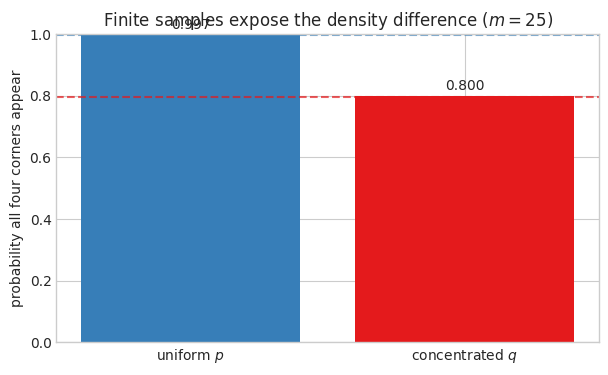

In [6]:
# Visualize the finite-sample effect directly.
def all_four_seen_indicators(weights, n_samples=5000, m=25):
    samples = rng.choice(4, size=(n_samples, m), p=weights)
    return np.array([len(np.unique(row)) == 4 for row in samples])

empirical = [all_four_seen_indicators(weights).mean() for weights in (p, q)]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['uniform $p$', 'concentrated $q$'], empirical, color=['#377eb8', '#e41a1c'])
ax.axhline(all_seen_p, color='#377eb8', ls='--', alpha=.7)
ax.axhline(all_seen_q, color='#e41a1c', ls='--', alpha=.7)
ax.set_ylim(0, 1); ax.set_ylabel('probability all four corners appear')
ax.set_title('Finite samples expose the density difference ($m=25$)')
for bar, value in zip(bars, empirical):
    ax.text(bar.get_x() + bar.get_width()/2, value + .02, f'{value:.3f}', ha='center')
plt.show()

## Interpretation

The support-topology null would regard these distributions as equal because their square support is identical. The locked metric-measure null does not: it includes how probability mass is distributed over that support. Therefore SC-B can reject this example legitimately. Such a rejection is evidence of a difference visible to the fixed-size barcode law, but it should not be called a purely topological effect.

Conversely, failure to reject the barcode-law null would not prove $p=q$. It would only say that this particular fixed-size barcode representation did not detect a difference.

In [7]:
# Save the main explanatory images for reports or slides.
output_file = 'same_square_different_density.png'
fig.savefig(output_file, dpi=180, bbox_inches='tight')
print('Saved:', Path(output_file).resolve())
try:
    from google.colab import files
    files.download(output_file)
    print('Downloaded:', output_file)
except Exception as e:
    print('(Not on Colab / download skipped):', e)

Saved: /home/hugo_souto/Stuff/Research/Pointcloud_Equality_Testing/notebooks/same_square_different_density.png
(Not on Colab / download skipped): No module named 'google'
